In [1]:
# https://pandas.pydata.org/
import pandas as pd

# https://geopandas.org/en/stable/
import geopandas as gpd

## Using pandas

In [2]:
df_cops = pd.read_csv("columbia-police-calls.csv")

In [3]:
df_cops.head()

,InNum,CallDateTime,Address,ExtNatureDisplayName,Report,PolArea,DOW,Hour
0,2026204593,7/28/2026 7:12:11 AM,11300 BLOCK S AIRPORT DR,PARKING VIOLATION,NaN,80A,Tuesday,7
1,2026204592,7/28/2026 7:06:54 AM,1300 BLOCK VANDIVER DR,DISTURBANCE,NaN,30,Tuesday,7
2,2026204591,7/28/2026 7:03:39 AM,11300 BLOCK S AIRPORT DR,PARKING VIOLATION,NaN,80A,Tuesday,7
3,2026204589,7/28/2026 6:52:55 AM,1300 BLOCK BOWLING ST,911 CHECKS,NaN,30,Tuesday,6
4,2026204588,7/28/2026 6:50:16 AM,W VAWTER SCHOOL RD/S OLD MILL CREEK RD,SUSPICIOUS PERSON,NaN,60,Tuesday,6


### Exercise: Geocode addresses
Write a custom function that uses `pyproj` or `geopandas` to geocode the addresses in the police data (bonus: cache the results to avoid geocoding the same place twice). Use the `apply` method to apply this function to the dataframe and save the coordinates as values in a new column.

#### ?????
Alternatively: Write a prompt to an LLM to generate the code.

## Using geopandas

In [4]:
df_fire = pd.read_csv("columbia-fire-calls.csv")

# convert to geodataframe
gdf = gpd.GeoDataFrame(
    df_fire,
    geometry=gpd.points_from_xy(
        df_fire["geox"],
        df_fire["geoy"]
    ),
    # central missouri state plane
    crs="ESRI:102697"
)

# reproject to wgs84
gdf = gdf.to_crs("EPSG:4326")

gdf.head()

,InNum,CallDateTime,Address,AptLot,geox,geoy,ExtNatureDisplayName,Report,PolArea,DOW,Hour,Agency,geometry
0,2026204897,7/28/2026 12:45:51 PM,652 N RANGELINE RD,,1724936.25,1137060.63,Fire Alarm,26002542.0,114,Tuesday,12,BCFD,POINT (-92.20278 38.95589)
1,2026204874,7/28/2026 12:23:37 PM,1107 ELLETA BLVD,,1690681.13,1144015.00,Medical Response,2609666.0,30,Tuesday,12,CFD,POINT (-92.32319 38.97523)
2,2026204862,7/28/2026 12:13:26 PM,RIDGE RD/S WEST BLVD,,1682212.25,1133759.13,Electrical Hazard,2609665.0,50,Tuesday,12,CFD,POINT (-92.35304 38.94712)
3,2026204844,7/28/2026 11:49:11 AM,901 JEWELL AVE,,1685564.25,1139062.25,Medical Response,2609664.0,20,Tuesday,11,CFD,POINT (-92.34122 38.96166)
4,2026204842,7/28/2026 11:46:59 AM,1012 SMILEY LN,,1690341.88,1150389.00,Medical Response,2609663.0,10,Tuesday,11,CFD,POINT (-92.32434 38.99274)


<Axes: >

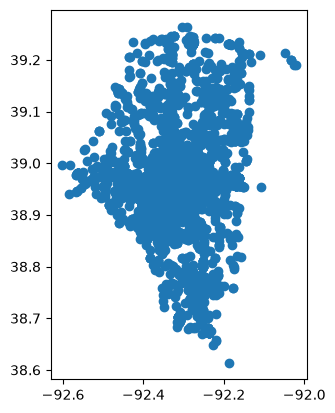

In [5]:
gdf.plot()

## Exercise: 